In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [5]:
# Đọc file CSV
file_path = "Raw_data/raw_data_train.csv"
train_df = pd.read_csv(file_path)

# Hiển thị thông tin cơ bản về DataFrame
print(train_df.info())
# Hiển thị 5 dòng đầu tiên của DataFrame
print(train_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82060 entries, 0 to 82059
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         82060 non-null  object 
 1   hour         82060 non-null  object 
 2   temperature  82060 non-null  float64
 3   weather      82031 non-null  object 
 4   wind_speed   82056 non-null  float64
 5   wind_angle   82060 non-null  float64
 6   humidity     82059 non-null  float64
 7   pressure     82038 non-null  float64
 8   visibility   36694 non-null  float64
dtypes: float64(6), object(3)
memory usage: 5.6+ MB
None
         date             hour  temperature         weather  wind_speed  \
0  2019-01-01  00:00Tue, 1 Jan         19.0  Partly cloudy.         6.0   
1  2019-01-01            00:30         19.0  Partly cloudy.         4.0   
2  2019-01-01            01:00         19.0  Partly cloudy.         6.0   
3  2019-01-01            01:30         19.0  Partly cloudy.         6.0  

In [8]:
# Đọc file CSV
file_path = "Raw_data/raw_data_test.csv"
test_df = pd.read_csv(file_path)

# Hiển thị thông tin cơ bản về DataFrame
print(test_df.info())
# Hiển thị 5 dòng đầu tiên của DataFrame
print(test_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22932 entries, 0 to 22931
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         22932 non-null  object 
 1   hour         22932 non-null  object 
 2   temperature  22932 non-null  float64
 3   weather      22932 non-null  object 
 4   wind_speed   22932 non-null  float64
 5   wind_angle   22932 non-null  float64
 6   humidity     22932 non-null  float64
 7   pressure     22931 non-null  float64
 8   visibility   5833 non-null   float64
dtypes: float64(6), object(3)
memory usage: 1.6+ MB
None
         date             hour  temperature weather  wind_speed  wind_angle  \
0  2024-01-01  00:00Mon, 1 Jan         22.0    Fog.         4.0       320.0   
1  2024-01-01            00:30         23.0    Fog.         2.0       340.0   
2  2024-01-01            01:00         22.0    Fog.         2.0       320.0   
3  2024-01-01            01:30         22.0    Fog.      

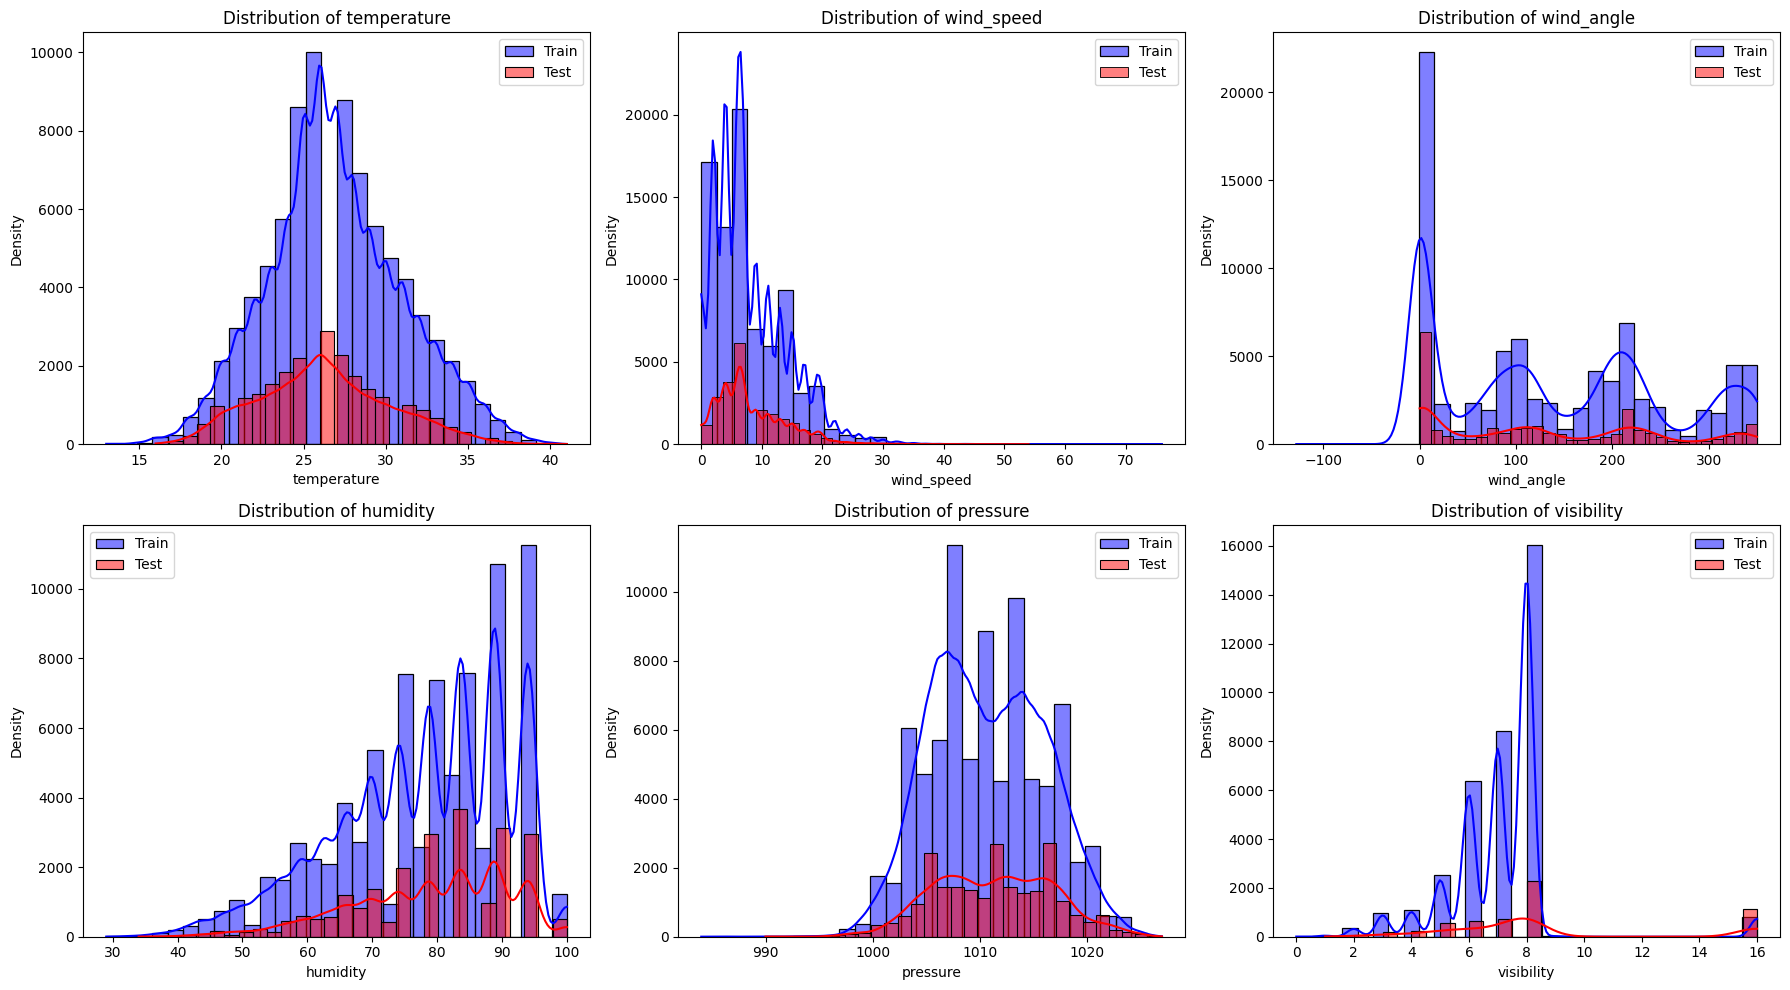

In [11]:
# 1. Vẽ biểu đồ phân phối các biến số cho cả train và test
numeric_cols = train_df.select_dtypes(include=["float64", "int64"]).columns
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / 3)

plt.figure(figsize=(18, 5 * n_rows))
for i, col in enumerate(numeric_cols, 1):
    # Biểu đồ cho tập huấn luyện
    plt.subplot(n_rows, 3, i)
    sns.histplot(train_df[col].dropna(), kde=True, bins=30, color='blue', alpha=0.5, label='Train')
    sns.histplot(test_df[col].dropna(), kde=True, bins=30, color='red', alpha=0.5, label='Test')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
plt.tight_layout()
plt.show()



🌀 Số lượng giá trị weather khác nhau trong tập train: 90
📋 Danh sách các giá trị weather trong tập train:
- Broken clouds.
- Clear.
- Extremely hot.
- Fog.
- Haze.
- Heavy rain. Broken clouds.
- Heavy rain. Cloudy.
- Heavy rain. Fog.
- Heavy rain. More clouds than sun.
- Heavy rain. Mostly cloudy.
- Heavy rain. Overcast.
- Heavy rain. Partly cloudy.
- Hot.
- Light rain. Broken clouds.
- Light rain. Cloudy.
- Light rain. Fog.
- Light rain. More clouds than sun.
- Light rain. Mostly cloudy.
- Light rain. Overcast.
- Light rain. Partly cloudy.
- Light rain. Partly sunny.
- Light rain. Passing clouds.
- Light rain. Scattered clouds.
- Lots of rain. Broken clouds.
- Lots of rain. Cloudy.
- Lots of rain. More clouds than sun.
- Lots of rain. Mostly cloudy.
- Lots of rain. Partly cloudy.
- Lots of rain. Partly sunny.
- Mild.
- More clouds than sun.
- Mostly cloudy.
- Overcast.
- Partly cloudy.
- Partly sunny.
- Passing clouds.
- Rain showers. Broken clouds.
- Rain showers. Cloudy.
- Rain sho

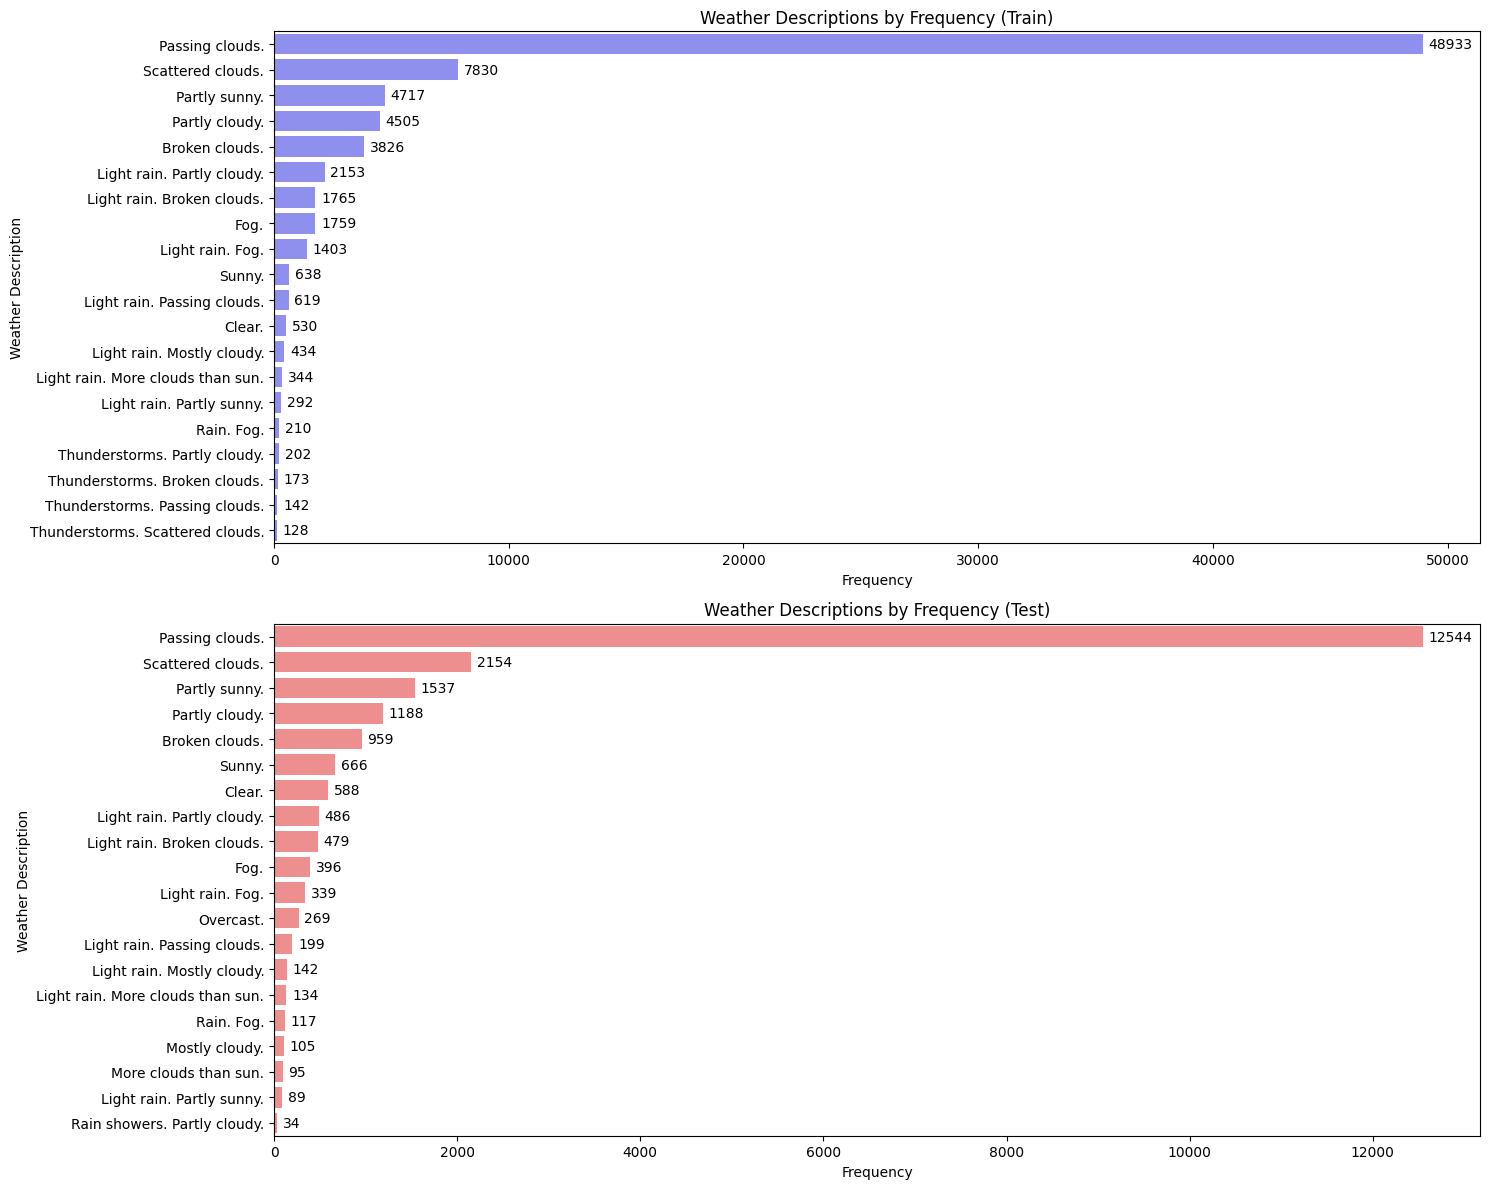

In [17]:
# 2. Xem các giá trị unique của cột weather cho cả train và test
unique_weather_train = train_df["weather"].dropna().unique()
unique_weather_test = test_df["weather"].dropna().unique()
print(f"\n🌀 Số lượng giá trị weather khác nhau trong tập train: {len(unique_weather_train)}")
print("📋 Danh sách các giá trị weather trong tập train:")
for val in sorted(unique_weather_train):
    print("-", val)

print(f"\n🦤 Số lượng giá trị weather khác nhau trong tập test: {len(unique_weather_test)}")
print("📋 Các giá trị weather trong tập test:")
for val in sorted(unique_weather_test):
    print(f"- {val}")

# 3. Vẽ biểu đồ tần suất cho các giá trị weather của train và test với giá trị trên mỗi bar
plt.figure(figsize=(15, 12))

# Biểu đồ cho tập huấn luyện
plt.subplot(2, 1, 1)
weather_counts_train = train_df['weather'].value_counts().head(20)
ax1 = sns.barplot(x=weather_counts_train.values, y=weather_counts_train.index, color='blue', alpha=0.5)
for i, v in enumerate(weather_counts_train.values):
    ax1.text(v + 0.005 * weather_counts_train.values.max(), i, str(v), fontsize=10, ha='left', va='center')
plt.title('Weather Descriptions by Frequency (Train)')
plt.xlabel('Frequency')
plt.ylabel('Weather Description')

# Biểu đồ cho tập kiểm thử
plt.subplot(2, 1, 2)
weather_counts_test = test_df['weather'].value_counts().head(20)
ax2 = sns.barplot(x=weather_counts_test.values, y=weather_counts_test.index, color='red', alpha=0.5)
for i, v in enumerate(weather_counts_test.values):
    ax2.text(v + 0.005 * weather_counts_test.values.max(), i, str(v), fontsize=10, ha='left', va='center')
plt.title('Weather Descriptions by Frequency (Test)')
plt.xlabel('Frequency')
plt.ylabel('Weather Description')

plt.tight_layout()
plt.show()